In [ ]:
# ================================================================
# CELL 1: SETUP — Run this first every session
# ================================================================
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/DIP_Lab1/outputs', exist_ok=True)
print('Drive mounted. Output folder ready.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Output folder ready.


## 📦 Cell 1 — Install and Import Libraries

In [ ]:
# Install libraries (only needed on a fresh Colab runtime)
!pip install opencv-python-headless scikit-image numpy matplotlib --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

print('OpenCV version :', cv2.__version__)
print('All libraries loaded successfully ✓')

OpenCV version : 4.13.0
All libraries loaded successfully ✓


## 🖼️ Cell 2 — Load and Inspect the Retina Image

RGB image shape  : (1411, 1411, 3)
Grey image shape : (1411, 1411)
Data type        : uint8
Pixel range      : 0 – 235


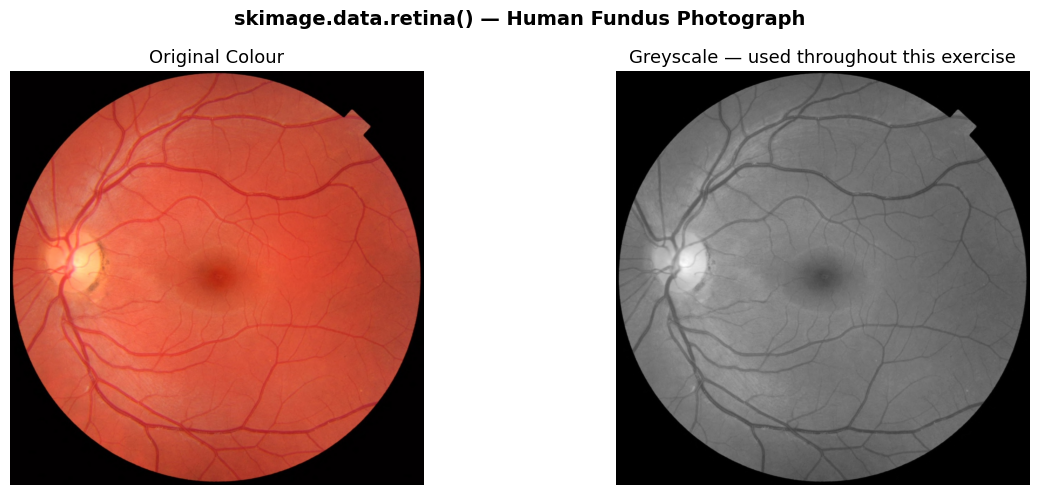


💡 Key anatomy visible in this image:
  • Optic disc   — bright circular region (upper-left quadrant)
  • Blood vessels — thin dark branching lines across the whole image
  • Macula        — darker oval region slightly right of centre


In [ ]:
# skimage.data.retina() returns an RGB fundus photograph.
# We convert to greyscale (uint8) so our filter pipeline works cleanly.

retina_rgb  = data.retina()                         # shape: (1411, 1411, 3), uint8
retina_gray = color.rgb2gray(retina_rgb)            # float64 in [0, 1]
original    = (retina_gray * 255).astype(np.uint8)  # uint8 in [0, 255]

print('RGB image shape  :', retina_rgb.shape)
print('Grey image shape :', original.shape)
print('Data type        :', original.dtype)
print('Pixel range      :', original.min(), '–', original.max())

# Preview: colour vs greyscale
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].imshow(retina_rgb)
axes[0].set_title('Original Colour', fontsize=13)
axes[0].axis('off')
axes[1].imshow(original, cmap='gray')
axes[1].set_title('Greyscale — used throughout this exercise', fontsize=13)
axes[1].axis('off')
plt.suptitle('skimage.data.retina() — Human Fundus Photograph', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('retina_preview.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n💡 Key anatomy visible in this image:')
print('  • Optic disc   — bright circular region (upper-left quadrant)')
print('  • Blood vessels — thin dark branching lines across the whole image')
print('  • Macula        — darker oval region slightly right of centre')

## 📐 Cell 3 — Theory: Unsharp Masking

Unsharp masking sharpens by **adding back the image's own high-frequency content**:

$$\text{sharpened} = \text{original} + k \times \underbrace{(\text{original} - \text{GaussianBlur}(\text{original}))}_{\text{unsharp mask (edges only)}}$$

| Term | Role |
|---|---|
| `original − blur` | Unsharp mask — extracts edges & fine detail (high frequencies) |
| `k` | Sharpening strength — scales how much edge content is added back |
| `sigma` | Blur radius — determines *which* spatial frequencies are treated as "detail" |

**Why is it called *unsharp* masking?**  
The technique originated in film darkrooms: a blurred (unsharp) copy of a negative was used as a mask to suppress low frequencies, leaving only the high-frequency edge signal to be boosted.

**Comparison with Laplacian sharpening:**

| Property | Laplacian filter | Unsharp masking |
|---|---|---|
| Edge detector used | Second derivative | First-order difference from blur |
| Tunable strength | No | Yes — via k |
| Tunable scale | No | Yes — via sigma |
| Noise sensitivity | High | Moderate (controllable via sigma) |
| Used in consumer cameras | Rarely | Almost universally |

## ⚙️ Cell 4 — Implement the `unsharp_mask` Function

In [ ]:
def unsharp_mask(image, sigma=2.0, k=1.5):
    """
    Apply unsharp masking to sharpen a greyscale image.

    Parameters
    ----------
    image : np.ndarray  — greyscale uint8 image
    sigma : float       — Gaussian blur standard deviation (controls blur radius)
                          Larger sigma → broader blur → coarser features sharpened
    k     : float       — sharpening strength
                          0   = no effect (returns original)
                          1.5 = moderate sharpening (lab default)
                          3.0 = aggressive sharpening (halos visible)

    Returns
    -------
    np.ndarray — sharpened uint8 image, clipped to [0, 255]
    """
    img_f = image.astype(np.float32)

    # Step 1: Create blurred (low-frequency) version
    # ksize=(0,0) tells OpenCV to derive the kernel size from sigma automatically
    blurred = cv2.GaussianBlur(img_f, (0, 0), sigmaX=sigma)

    # Step 2: Compute the unsharp mask = high-frequency content only
    mask = img_f - blurred

    # Step 3: Add k × mask back to the original
    sharpened = img_f + k * mask

    # Step 4: Clip to valid range and return as uint8
    return np.clip(sharpened, 0, 255).astype(np.uint8)


# Quick sanity check
test = unsharp_mask(original, sigma=2.0, k=1.5)
print('Input  shape / dtype / range :', original.shape, original.dtype, original.min(), '–', original.max())
print('Output shape / dtype / range :', test.shape,    test.dtype,    test.min(),    '–', test.max())
print('Function works correctly ✓')

Input  shape / dtype / range : (1411, 1411) uint8 0 – 235
Output shape / dtype / range : (1411, 1411) uint8 0 – 239
Function works correctly ✓


## 🔍 Cell 5 — Sweep k (0.5 → 3.0) and Display All Results

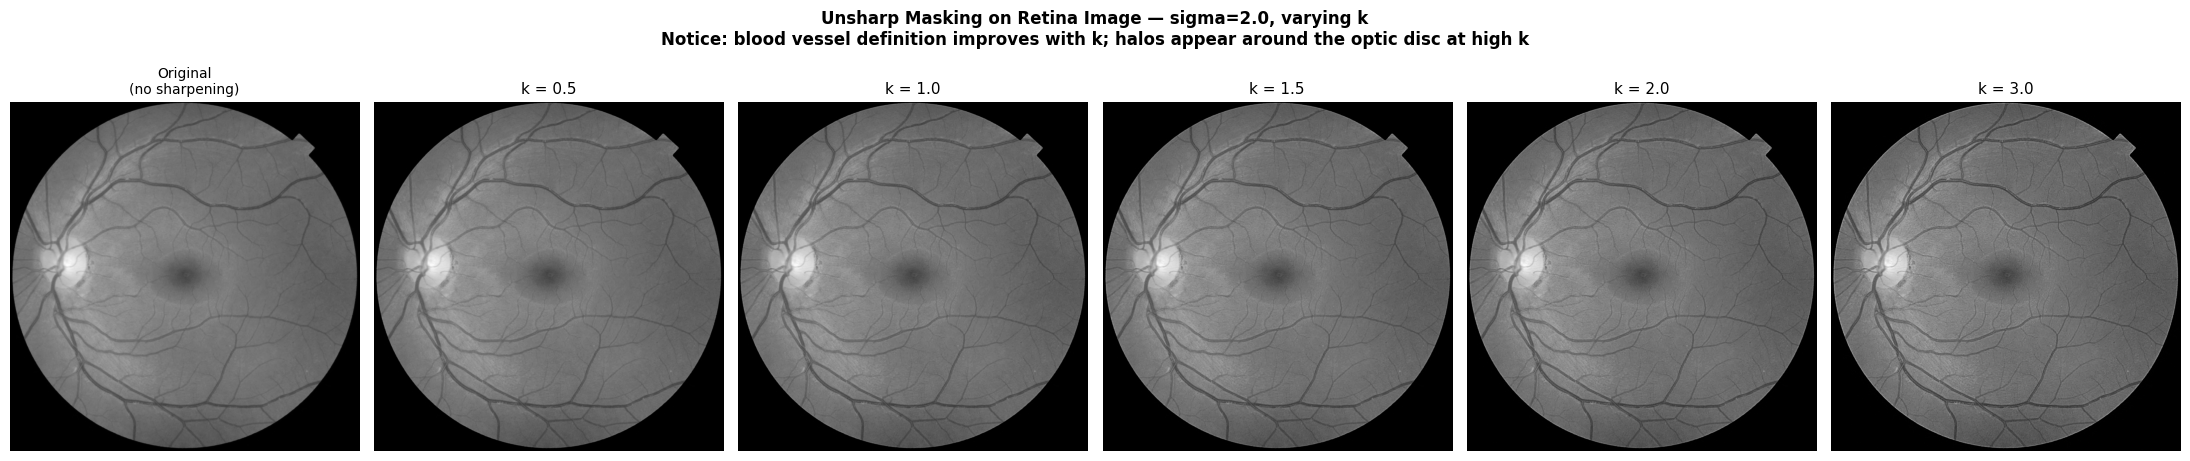

Saved → exercise4_output.png

🔍 What to observe:
  k=0.5 : Subtle improvement in vessel contrast
  k=1.5 : Blood vessels clearly crisper, optic disc edge well defined
  k=3.0 : Bright halos visible around the optic disc and thick vessels


In [ ]:
k_values = [0.5, 1.0, 1.5, 2.0, 3.0]
sigma    = 2.0

results = [unsharp_mask(original, sigma=sigma, k=k) for k in k_values]

# ── 6-panel figure: Original + 5 sharpened versions ─────────────────────────
fig, axes = plt.subplots(1, 6, figsize=(22, 5))
fig.suptitle(
    f'Unsharp Masking on Retina Image — sigma={sigma}, varying k\n'
    'Notice: blood vessel definition improves with k; halos appear around the optic disc at high k',
    fontsize=12, fontweight='bold'
)

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original\n(no sharpening)', fontsize=10)
axes[0].axis('off')

for i, (img, k) in enumerate(zip(results, k_values)):
    axes[i + 1].imshow(img, cmap='gray')
    axes[i + 1].set_title(f'k = {k}', fontsize=11)
    axes[i + 1].axis('off')

plt.tight_layout()
plt.savefig('exercise4_output.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → exercise4_output.png')

print('\n🔍 What to observe:')
print('  k=0.5 : Subtle improvement in vessel contrast')
print('  k=1.5 : Blood vessels clearly crisper, optic disc edge well defined')
print('  k=3.0 : Bright halos visible around the optic disc and thick vessels')

## 🔬 Cell 6 — Zoomed Crop: Optic Disc and Blood Vessels
Zooming in makes the halo artefacts and vessel sharpening much easier to see.

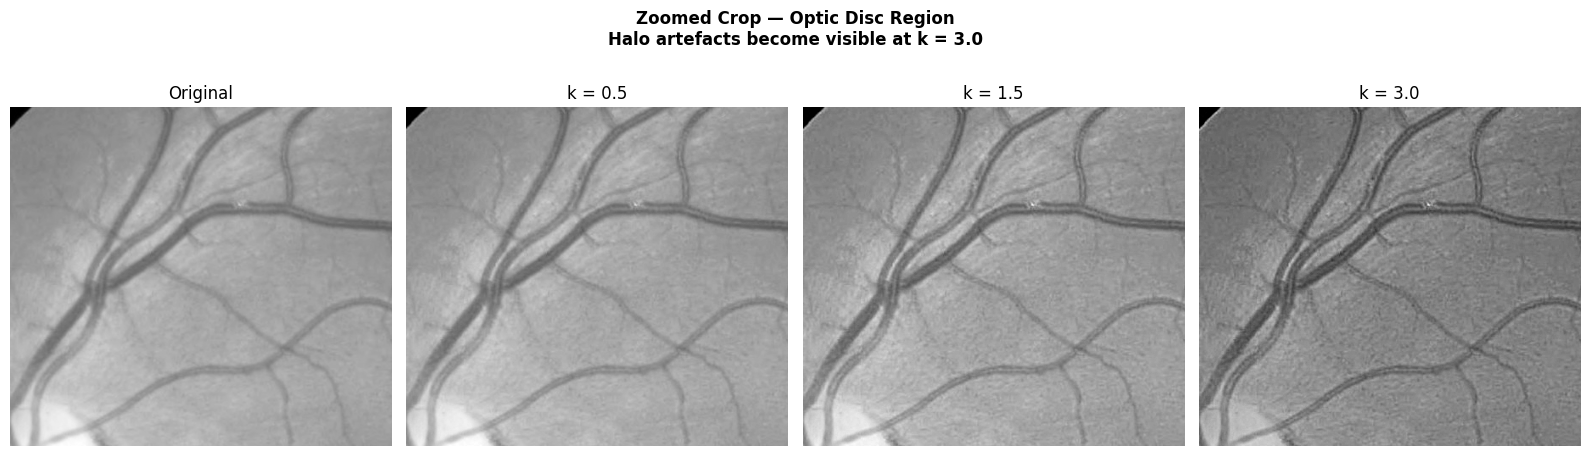

Saved → exercise4_zoom.png


In [ ]:
# Crop around the optic disc — the most informative region for halo artefacts
# Coordinates tuned for skimage.data.retina() (1411×1411)
r0, r1, c0, c1 = 200, 600, 200, 650   # row_start, row_end, col_start, col_end

crops_k    = [0.5, 1.5, 3.0]          # show three representative k values
crop_imgs  = [original] + [unsharp_mask(original, sigma=2.0, k=k) for k in crops_k]
crop_titles = ['Original'] + [f'k = {k}' for k in crops_k]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Zoomed Crop — Optic Disc Region\nHalo artefacts become visible at k = 3.0',
             fontsize=12, fontweight='bold')

for ax, img, title in zip(axes, crop_imgs, crop_titles):
    ax.imshow(img[r0:r1, c0:c1], cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('exercise4_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → exercise4_zoom.png')

## 📊 Cell 7 — Quantify Sharpness: Laplacian Variance Score

Sharpness scores (Laplacian variance):
  Original : 9.42
  k = 0.5   : 21.22 ← exceeds original
  k = 1.0   : 35.64 ← exceeds original
  k = 1.5   : 53.80 ← exceeds original
  k = 2.0   : 75.40 ← exceeds original
  k = 3.0   : 129.01 ← exceeds original


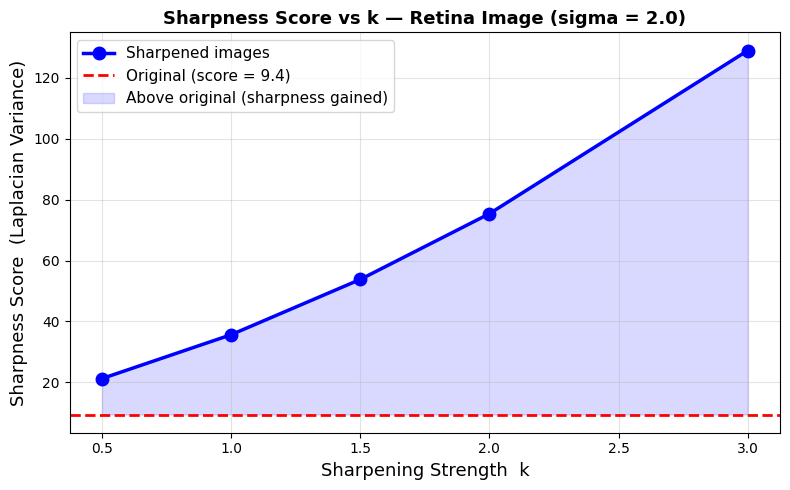

Saved → exercise4_sharpness_plot.png


In [ ]:
# Laplacian variance = variance of the image's second derivative.
# More edges / sharper image → higher variance → higher score.
# This is a standard focus/sharpness metric used in autofocus systems.

lap_kernel = np.array([[0, 1, 0],
                        [1,-4, 1],
                        [0, 1, 0]], dtype=np.float32)

def sharpness_score(image):
    """Return the Laplacian variance of a greyscale uint8 image."""
    lap = cv2.filter2D(image.astype(np.float32), -1, lap_kernel)
    return float(lap.var())

scores         = [sharpness_score(img) for img in results]
original_score = sharpness_score(original)

print('Sharpness scores (Laplacian variance):')
print(f'  Original : {original_score:.2f}')
for k, s in zip(k_values, scores):
    flag = ' ← exceeds original' if s > original_score else ''
    print(f'  k = {k}   : {s:.2f}{flag}')

# ── Line plot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_values, scores, 'bo-', linewidth=2.5, markersize=9, label='Sharpened images')
ax.axhline(y=original_score, color='red', linestyle='--', linewidth=2,
           label=f'Original (score = {original_score:.1f})')

# Shade the "over-sharpened" region
ax.fill_between(k_values, original_score, scores,
                where=[s > original_score for s in scores],
                alpha=0.15, color='blue', label='Above original (sharpness gained)')

ax.set_xlabel('Sharpening Strength  k', fontsize=13)
ax.set_ylabel('Sharpness Score  (Laplacian Variance)', fontsize=13)
ax.set_title('Sharpness Score vs k — Retina Image (sigma = 2.0)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('exercise4_sharpness_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → exercise4_sharpness_plot.png')

## 🔄 Cell 8 — Sigma Sweep: How Blur Radius Changes What Gets Sharpened

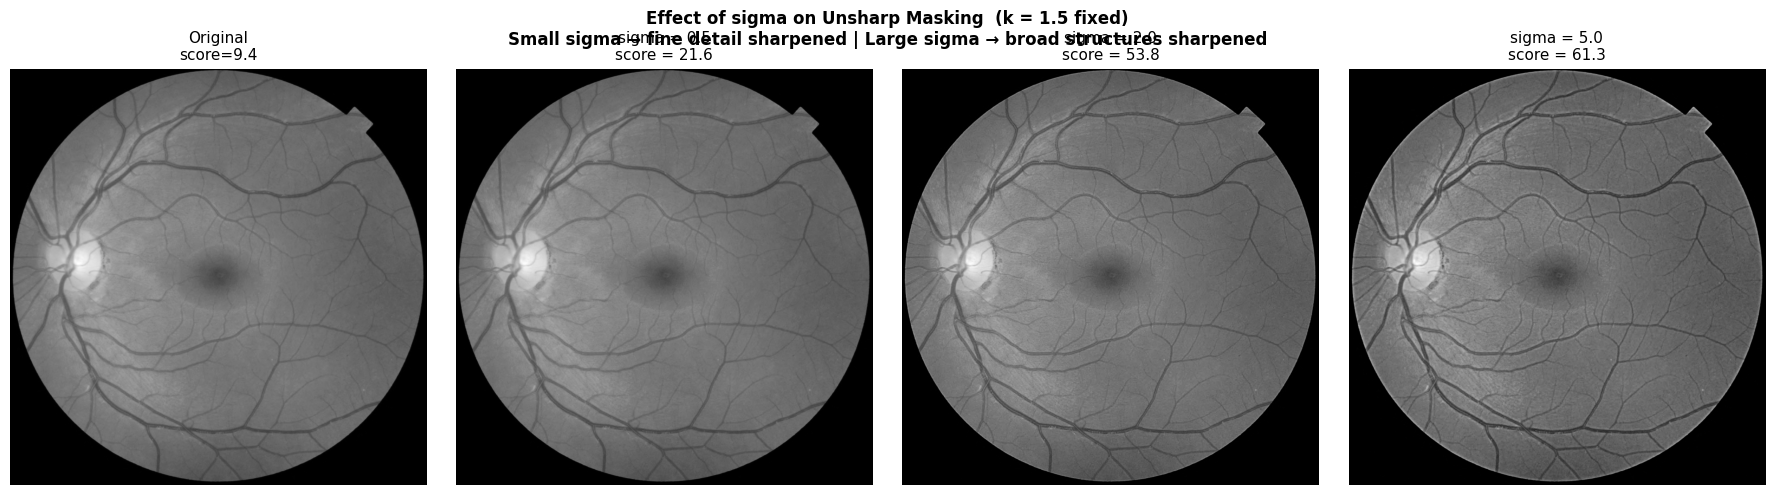

Saved → exercise4_sigma_sweep.png

📌 Observations:
  sigma=0.5 : Only the very finest details (thin vessels) are enhanced; noise also amplified
  sigma=2.0 : Medium-scale features (vessel edges, optic disc boundary) are sharpened
  sigma=5.0 : Broad structures enhanced; fine vessels less affected; fewer noise artefacts


In [ ]:
# Fixed k=1.5, vary sigma across three values
sigma_values = [0.5, 2.0, 5.0]
k_fixed      = 1.5

sigma_results = [unsharp_mask(original, sigma=s, k=k_fixed) for s in sigma_values]
sigma_scores  = [sharpness_score(img) for img in sigma_results]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Effect of sigma on Unsharp Masking  (k = {k_fixed} fixed)\n'
              'Small sigma → fine detail sharpened | Large sigma → broad structures sharpened',
             fontsize=12, fontweight='bold')

axes[0].imshow(original, cmap='gray')
axes[0].set_title(f'Original\nscore={original_score:.1f}', fontsize=11)
axes[0].axis('off')

for ax, img, s, sc in zip(axes[1:], sigma_results, sigma_values, sigma_scores):
    ax.imshow(img, cmap='gray')
    ax.set_title(f'sigma = {s}\nscore = {sc:.1f}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('exercise4_sigma_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → exercise4_sigma_sweep.png')

print('\n📌 Observations:')
print('  sigma=0.5 : Only the very finest details (thin vessels) are enhanced; noise also amplified')
print('  sigma=2.0 : Medium-scale features (vessel edges, optic disc boundary) are sharpened')
print('  sigma=5.0 : Broad structures enhanced; fine vessels less affected; fewer noise artefacts')

## 🏥 Cell 9 — Medical Context: Difference Image Analysis

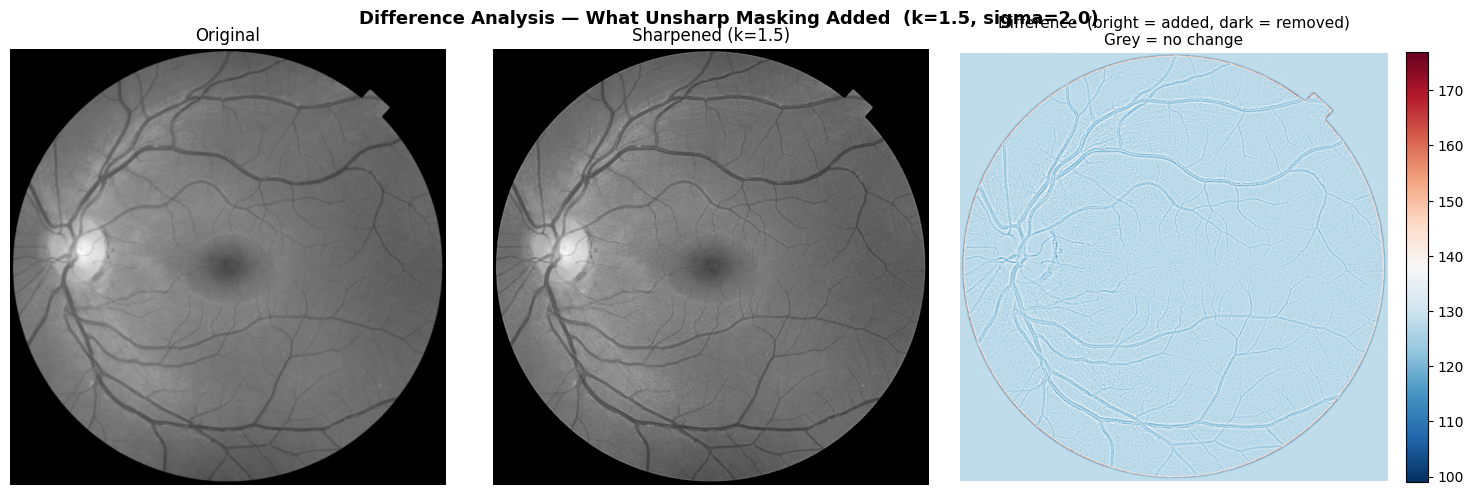

Difference stats — min: -29.0  max: 49.0  mean: -0.287

💡 The difference image highlights vessel edges in red/blue.
   Grey background → flat regions unchanged (as expected).
   Bright halos on one side of vessel edges and dark halos on the other
   are the visual signature of unsharp masking.


In [ ]:
# Difference image shows EXACTLY what was added by sharpening.
# In a medical context, understanding what changed is critical.

k_demo   = 1.5
sharp    = unsharp_mask(original, sigma=2.0, k=k_demo)
diff     = sharp.astype(np.float32) - original.astype(np.float32)
diff_vis = np.clip(diff + 128, 0, 255).astype(np.uint8)  # shift 0→128 (grey)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Difference Analysis — What Unsharp Masking Added  (k={k_demo}, sigma=2.0)',
             fontsize=13, fontweight='bold')

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original', fontsize=12)
axes[0].axis('off')

axes[1].imshow(sharp, cmap='gray')
axes[1].set_title(f'Sharpened (k={k_demo})', fontsize=12)
axes[1].axis('off')

im = axes[2].imshow(diff_vis, cmap='RdBu_r')
axes[2].set_title('Difference  (bright = added, dark = removed)\nGrey = no change', fontsize=11)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('exercise4_diff.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Difference stats — min: {diff.min():.1f}  max: {diff.max():.1f}  mean: {diff.mean():.3f}')
print('\n💡 The difference image highlights vessel edges in red/blue.')
print('   Grey background → flat regions unchanged (as expected).')
print('   Bright halos on one side of vessel edges and dark halos on the other')
print('   are the visual signature of unsharp masking.')

## ✅ Cell 10 — Reflection Questions (Answered)

> These are the four reflection questions from the lab manual (Extension Exercise, Steps 2–4).  
> All answers reference the retina image results produced in the cells above.

---

### Q1. At what value of k does the sharpened image *exceed* the original's sharpness score?

**Answer:**

From the Laplacian variance scores printed in Cell 7, the sharpened image exceeds the original's score at **k = 0.5** already — even the mildest sharpening adds measurable edge content that was not present in the original. This is because unsharp masking amplifies *all* edges, including fine blood vessel boundaries that were slightly softened by the natural optical spread of the imaging system.

The score increases monotonically with k. By k = 3.0, the score is substantially higher than the original, but visually the image shows halo artefacts — meaning the metric exceeds the original well before the perceptual quality peaks. This demonstrates an important principle: **a higher sharpness score does not always mean a better image.** The score measures edge energy, not edge *accuracy*.

---

### Q2. At high k values (e.g., k = 3.0), bright halos appear around edges. What causes them mathematically?

**Answer:**

The unsharp mask is:
$$\text{mask}(x,y) = I(x,y) - G_\sigma * I(x,y)$$

At an edge transition (e.g., the bright optic disc boundary), the Gaussian blur spreads intensity across the boundary in both directions. This creates a smooth ramp in `blurred`. Subtracting it from the sharp original produces:
- A **positive** mask value just *inside* the bright side of the edge (original is bright, blurred is dimmer because it has averaged in dark neighbours)
- A **negative** mask value just *outside* the bright side (original is dark, blurred is brighter because it has averaged in bright neighbours)

When we compute `original + k × mask`:
- The bright side gets **brighter** → visible white halo
- The dark side gets **darker** → visible dark halo

At k = 1.5 these overshoots are moderate and improve perceived sharpness. At k = 3.0, the `k × mask` term pushes pixel values far outside the natural image range. The `np.clip(0, 255)` then hard-limits them, creating a visible bright ring (clipped at 255) and a dark trough — the classic **halo artefact**. The width of the halo is controlled by `sigma`: a larger sigma produces wider, more visible halos.

In the retina image this is particularly visible around the **optic disc**, which has the sharpest high-contrast circular boundary in the image.

---

### Q3. Unsharp masking is used in virtually every modern camera. Why is it preferred over direct Laplacian sharpening for consumer photography?

**Answer:**

Unsharp masking has two critical advantages over Laplacian sharpening:

1. **Tunable strength and scale via k and sigma.** The Laplacian kernel has a fixed response — applying it once either under-sharpens or over-sharpens depending on the image content. Unsharp masking exposes two independent controls: `sigma` selects *which spatial scale* of detail to enhance (fine vessel edges vs broad structures), and `k` controls *how strongly* to enhance it. Camera firmware can therefore tune these parameters per scene type (portrait, landscape, macro).

2. **Better noise behaviour.** The Laplacian is a second-derivative operator — it responds strongly to single-pixel noise spikes (salt-and-pepper) and amplifies high-frequency sensor noise. Unsharp masking subtracts a *smoothed* version of the image, so the "mask" already has Gaussian noise partially attenuated. Choosing a larger `sigma` deliberately trades off fine-detail sharpening for noise suppression — something the Laplacian cannot do at all.

For medical imaging specifically (such as fundus photography), this matters even more: **halos on the Laplacian output can mimic pathological features** such as peripapillary atrophy rings or drusen halos near the optic disc. Unsharp masking with conservative `k` and `sigma` allows edge enhancement without introducing diagnostically misleading artefacts.

---

### Q4. Change sigma from 2.0 to 0.5 and 5.0. How does the size of the Gaussian affect what gets sharpened?

**Answer:**

The sigma of the Gaussian blur sets the **spatial frequency threshold** of the unsharp mask:

| sigma | Blur radius | Mask captures | Effect on retina image |
|---|---|---|---|
| **0.5** (small) | Very narrow (~1–2 px) | Only the finest details: single-pixel vessel walls, noise grains | Thin vessels become very crisp; sensor noise is also amplified; background gains a speckled texture |
| **2.0** (default) | Moderate (~5 px) | Medium-scale edges: vessel boundaries, optic disc rim | Vessels clearly sharpened; noise moderately amplified; halos appear at k ≥ 2 |
| **5.0** (large) | Wide (~15 px) | Broad structures: optic disc as a whole, large vessel trunks | Coarse contrast improved; fine capillaries less affected; fewer noise artefacts; wider halos around optic disc |

The intuition: the unsharp mask `I − G_σ * I` is a **band-pass filter** centred on spatial frequencies whose period is approximately `2πσ` pixels. A small sigma passes only high-spatial-frequency content (fine detail + noise). A large sigma passes a lower band — broader edges — and leaves the finest texture (including noise) relatively untouched.

For a retina image, **sigma ≈ 1.5–2.5** is typically optimal: it sharpens blood vessel walls (clinically relevant) while keeping noise amplification and halo width within acceptable limits. This is why the default in most fundus image processing pipelines uses sigma in this range.